In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow import keras 
from tensorflow.keras import layers
import tensorflow as tf

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images[:15000,:,:]
train_labels = train_labels[:15000]
test_images = test_images[:2000,:,:]
test_labels = test_labels[:2000]  # labels are integers, not one-hot encoded
train_images.shape

(15000, 28, 28)

# Load MNIST dataset but only use first 15,000 images to speed run time

In [3]:
train_images = train_images.reshape((15000, 28 * 28))
train_images = train_images.astype("float32") / 255 
test_images = test_images.reshape((2000, 28 * 28))
test_images = test_images.astype("float32") / 255
print(test_images.shape)
train_images.shape

(2000, 784)


(15000, 784)

# Simple dense model with 512 in first layer, and 10 in last layer to classify images.  Default parameters in RMSProp and batch size 128, 25 epochs

https://keras.io/api/optimizers/rmsprop/

0.001
Epoch 1/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7931 - loss: 0.7223 - val_accuracy: 0.8900 - val_loss: 0.3519
Epoch 2/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9347 - loss: 0.2350 - val_accuracy: 0.8965 - val_loss: 0.3088
Epoch 3/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9547 - loss: 0.1573 - val_accuracy: 0.9265 - val_loss: 0.2292
Epoch 4/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9635 - loss: 0.1199 - val_accuracy: 0.9325 - val_loss: 0.2068
Epoch 5/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9756 - loss: 0.0900 - val_accuracy: 0.9390 - val_loss: 0.2001
Epoch 6/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9834 - loss: 0.0617 - val_accuracy: 0.9535 - val_loss: 0.1671
Epoch 7/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9892 - loss: 0.0464 - val_accuracy: 0.9520 - val_loss: 0.1567
Epoch 8/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9915 - loss: 0.0372 - val_accura

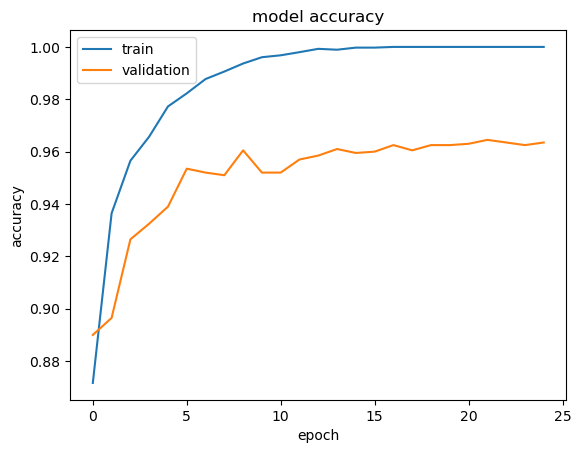

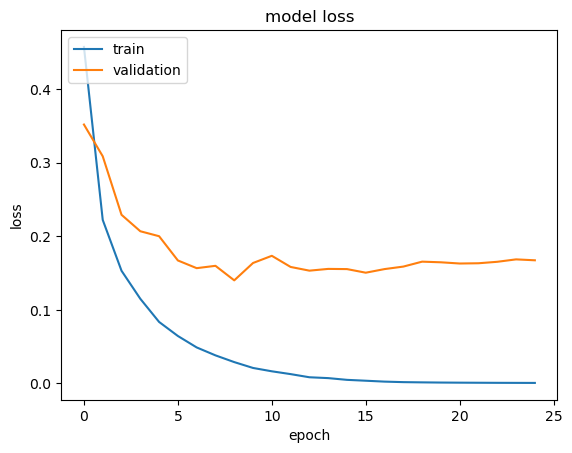

In [27]:
# RMSprop defaults to 0.001 learning rate

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
optimizer = tf.keras.optimizers.RMSprop()
print(optimizer.learning_rate.numpy())

model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])  # integer labels, not one-hot so we use sparse categorical crossentropy
history = model.fit(train_images, train_labels, epochs=25, batch_size=128, validation_data=(test_images, test_labels))

# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# Simple dense model with 512 in first layer, and 10 in last layer to classify images.  Default parameters in RMSProp and batch size 128, 25 epochs.
# Learning rate changed to 1 (default is 0.001)

Epoch 1/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4391 - loss: 7211.6621 - val_accuracy: 0.2365 - val_loss: 3.3931
Epoch 2/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2506 - loss: 13.0942 - val_accuracy: 0.2525 - val_loss: 2.4136
Epoch 3/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2243 - loss: 3.0764 - val_accuracy: 0.2230 - val_loss: 3.2922
Epoch 4/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2070 - loss: 2.3440 - val_accuracy: 0.2115 - val_loss: 2.9214
Epoch 5/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2151 - loss: 2.8735 - val_accuracy: 0.2370 - val_loss: 2.4079
Epoch 6/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2242 - loss: 2.4144 - val_accuracy: 0.1700 - val_loss: 2.9162
Epoch 7/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1860 - loss: 2.8763 - val_accuracy: 0.2275 - val_loss: 5.6049
Epoch 8/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2174 - loss: 2.6695 - val_accuracy

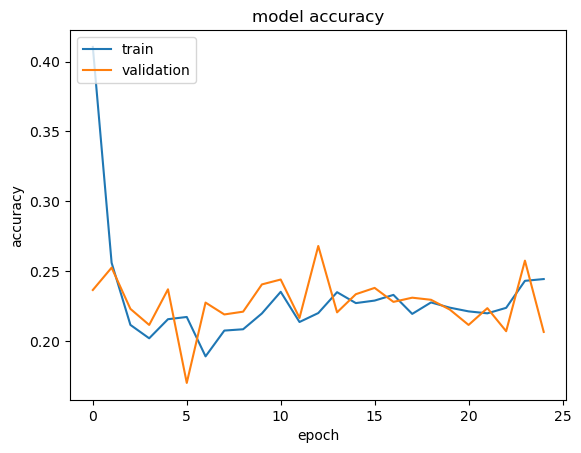

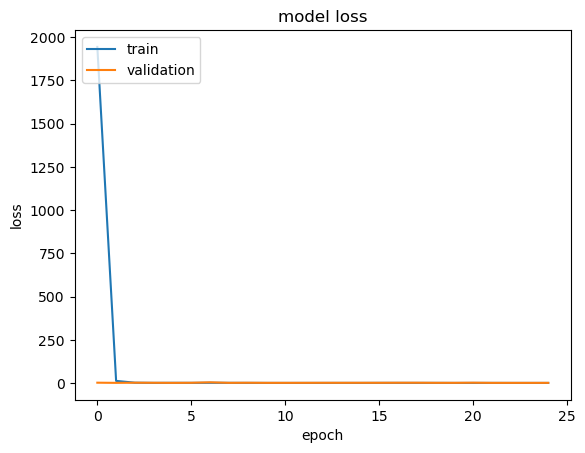

In [4]:
# learning rate = 1
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(tf.keras.optimizers.RMSprop(
    learning_rate=1.0),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_images, train_labels, epochs=25, batch_size=128, validation_data=(test_images, test_labels))
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# Simple dense model with 512 in first layer, and 10 in last layer to classify images.  Default parameters in RMSProp and batch size 128, 25 epochs
# Learning rate changed to 0.0001

Epoch 1/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5475 - loss: 1.7105 - val_accuracy: 0.8180 - val_loss: 0.8439
Epoch 2/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8660 - loss: 0.6281 - val_accuracy: 0.8530 - val_loss: 0.5576
Epoch 3/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8996 - loss: 0.4112 - val_accuracy: 0.8735 - val_loss: 0.4696
Epoch 4/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9112 - loss: 0.3567 - val_accuracy: 0.8775 - val_loss: 0.4214
Epoch 5/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9188 - loss: 0.3171 - val_accuracy: 0.8855 - val_loss: 0.3899
Epoch 6/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9220 - loss: 0.2945 - val_accuracy: 0.8905 - val_loss: 0.3636
Epoch 7/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9311 - loss: 0.2621 - val_accuracy: 0.8955 - val_loss: 0.3435
Epoch 8/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9359 - loss: 0.2436 - val_accuracy: 0.

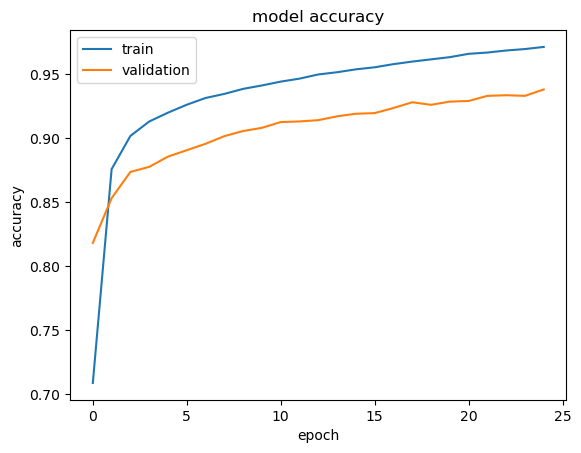

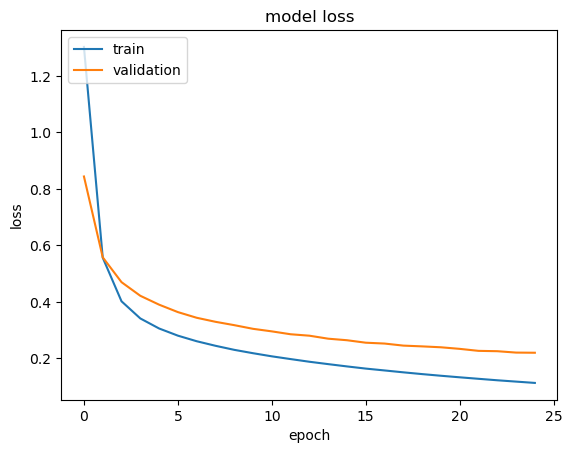

In [5]:
# learning rate = 0.0001
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(tf.keras.optimizers.RMSprop(
    learning_rate=0.0001),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_images, train_labels, epochs=25, batch_size=128, validation_data=(test_images, test_labels))
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# Simple dense model with 512 in first layer, and 10 in last layer to classify images.  Default parameters in Adam and batch size 128, 25 epochs
# Using Adam instead of RMSProp

https://keras.io/api/optimizers/adam/

0.001
Epoch 1/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7721 - loss: 0.8169 - val_accuracy: 0.8990 - val_loss: 0.3571
Epoch 2/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9387 - loss: 0.2249 - val_accuracy: 0.9235 - val_loss: 0.2559
Epoch 3/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9584 - loss: 0.1551 - val_accuracy: 0.9390 - val_loss: 0.2119
Epoch 4/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9711 - loss: 0.1120 - val_accuracy: 0.9425 - val_loss: 0.1915
Epoch 5/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9773 - loss: 0.0846 - val_accuracy: 0.9445 - val_loss: 0.1752
Epoch 6/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9843 - loss: 0.0622 - val_accuracy: 0.9505 - val_loss: 0.1656
Epoch 7/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9895 - loss: 0.0462 - val_accuracy: 0.9545 - val_loss: 0.1543
Epoch 8/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9914 - loss: 0.0368 - val_accura

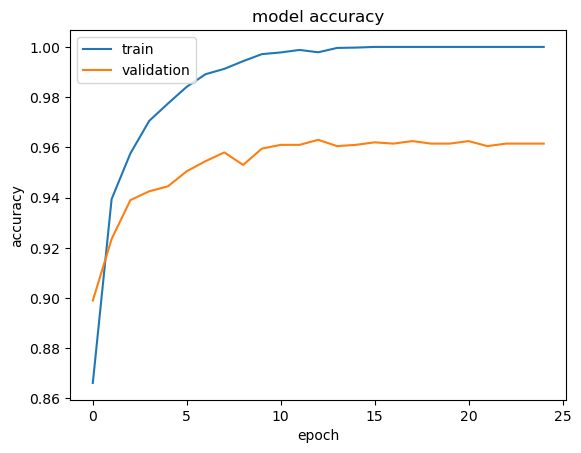

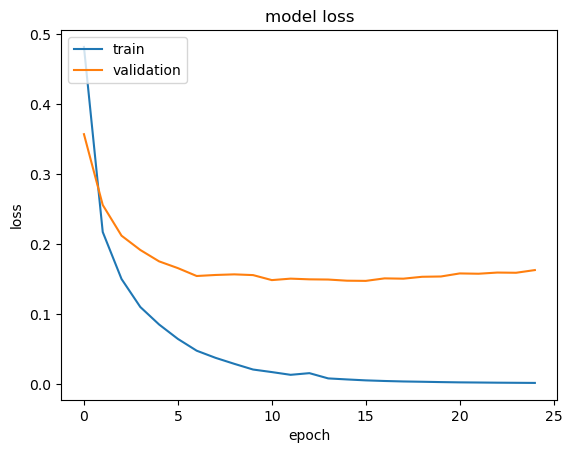

In [6]:
# Adam optimizer default learning rate = 0.001
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
optimizer = tf.keras.optimizers.Adam()  # or any other optimizer
print(optimizer.learning_rate.numpy())
model.compile(optimizer = optimizer,
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_images, train_labels, epochs=25, batch_size=128, validation_data=(test_images, test_labels))
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# Simple dense model with 512 in first layer, and 10 in last layer to classify images.  Default parameters in Adam and batch size 128, 25 epochs
# Adam learning rate changed to 1.0 (default 0.001)

1.0
Epoch 1/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2945 - loss: 987.8173 - val_accuracy: 0.2670 - val_loss: 4.8569
Epoch 2/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2296 - loss: 2.3515 - val_accuracy: 0.1845 - val_loss: 2.9877
Epoch 3/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2049 - loss: 2.2300 - val_accuracy: 0.2090 - val_loss: 2.0913
Epoch 4/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2099 - loss: 2.1002 - val_accuracy: 0.1425 - val_loss: 2.2973
Epoch 5/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1392 - loss: 2.3089 - val_accuracy: 0.1155 - val_loss: 2.3294
Epoch 6/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1079 - loss: 2.3282 - val_accuracy: 0.0950 - val_loss: 2.3113
Epoch 7/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1085 - loss: 2.3310 - val_accuracy: 0.1160 - val_loss: 2.3037
Epoch 8/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1118 - loss: 2.3134 - val_accura

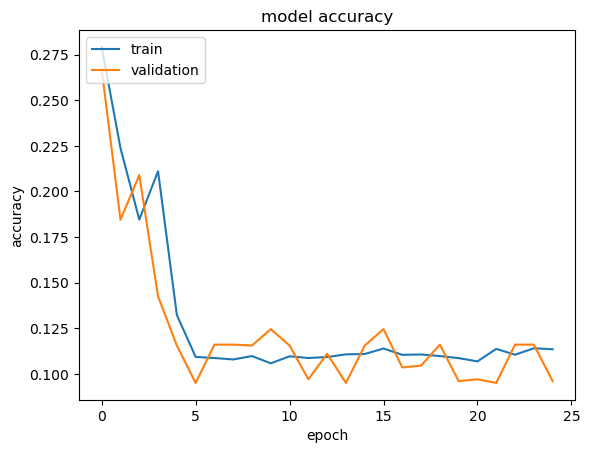

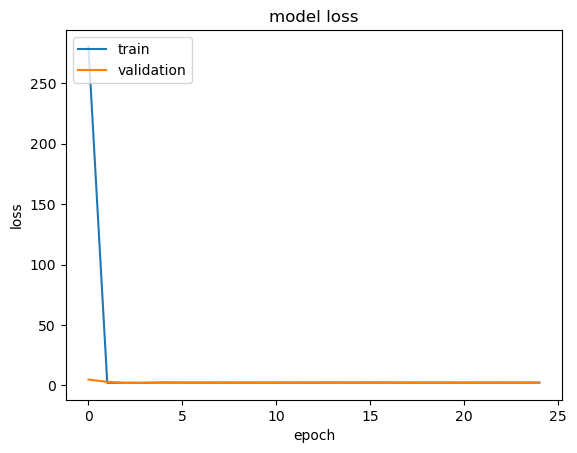

In [7]:
# Adam optimizer learning rate = 1.0
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
optimizer = tf.keras.optimizers.Adam(1.0)  # or any other optimizer
print(optimizer.learning_rate.numpy())
model.compile(optimizer = optimizer,
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_images, train_labels, epochs=25, batch_size=128, validation_data=(test_images, test_labels))
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# Simple dense model with 512 in first layer, and 10 in last layer to classify images.  Changed to SGD for optimizer, learning rate 0.001, and batch size 128, 25 epochs

https://keras.io/api/optimizers/sgd/

Epoch 1/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0953 - loss: 2.3178 - val_accuracy: 0.1635 - val_loss: 2.2293
Epoch 2/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2092 - loss: 2.1834 - val_accuracy: 0.3055 - val_loss: 2.1233
Epoch 3/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3933 - loss: 2.0635 - val_accuracy: 0.4400 - val_loss: 2.0240
Epoch 4/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5271 - loss: 1.9519 - val_accuracy: 0.5265 - val_loss: 1.9305
Epoch 5/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6015 - loss: 1.8509 - val_accuracy: 0.5865 - val_loss: 1.8421
Epoch 6/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6514 - loss: 1.7502 - val_accuracy: 0.6185 - val_loss: 1.7589
Epoch 7/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6829 - loss: 1.6608 - val_accuracy: 0.6430 - val_loss: 1.6804
Epoch 8/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7041 - loss: 1.5767 - val_accuracy: 0.

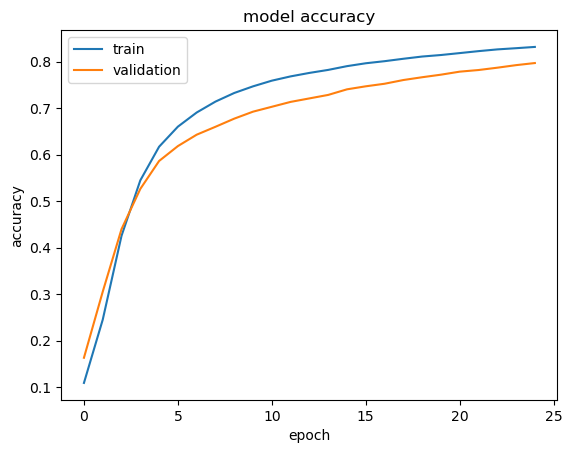

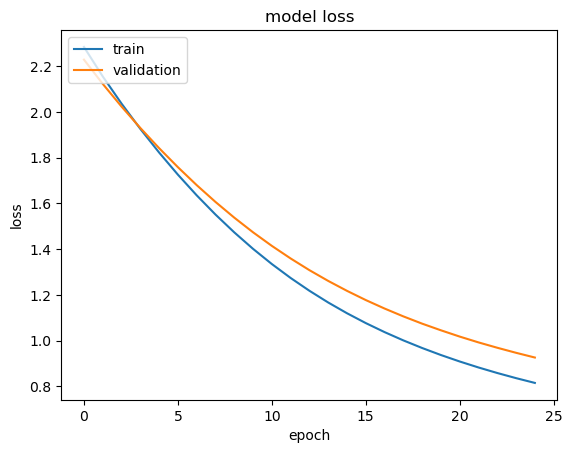

In [25]:
# SGD 
optimizer = keras.optimizers.SGD(learning_rate=0.001)  # default learning rate is 0.001
# SGD optimizer without exponential decay
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer = optimizer,
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_images, train_labels, epochs=25, batch_size=128, validation_data=(test_images, test_labels))
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

When to use SGD:

Deep Convolutional Neural Networks (CNNs): SGD (especially with momentum) is a standard for training deep CNNs and has achieved state-of-the-art results on many vision benchmarks. 
Better generalization: SGD tends to converge to flatter minima, which improves a model's ability to generalize to new, unseen data. 
When overfitting is a concern: Its "noisiness" can help the optimizer avoid poor local minima and improve generalization. 

When to use Adam:

Complex models and large datasets: Adam's combination of momentum and adaptive learning rates allows for faster and more stable convergence, making it excellent for complex models and large datasets. 
Transformers: Adam and AdamW are often preferred for training Transformer models over SGD. 
If you're using weight decay: Use AdamW, a variant of Adam, for more effective and transparent regularization compared to standard Adam when weight decay is applied. 

When to use RMSProp:

Recurrent Neural Networks (RNNs): RMSProp is particularly well-suited for RNNs and other models prone to vanishing or exploding gradients. 
Sparse Data: It effectively handles sparse data by dynamically adjusting learning rates based on recent gradient values. 
Stabilizing training: If your model is oscillating or diverging during training, RMSProp can help stabilize the process by adapting to the gradients. 

# Exponential Learning Rate
## Learning rate per batch

learning rate = initial_learning_rate * decay_rate ^ (step / decay_steps)

A step is one batch, not one epoch.  With batch size 128 and 15,000 images, there are 118 batches per epoch.

In [14]:
# The learning rate per batch.  Starts with learning rate=1 and goes down every 25 batches
for epoch in range(1, 26):
    for batch in range(1, 119):
        print("epoch: ", epoch, "batch: ",batch, "decay rate: ",1 * 0.7 ** (epoch * batch /25))

epoch:  1 batch:  1 decay rate:  0.9858342935750544
epoch:  1 batch:  2 decay rate:  0.9718692543886265
epoch:  1 batch:  3 decay rate:  0.9581020398475265
epoch:  1 batch:  4 decay rate:  0.9445298476259049
epoch:  1 batch:  5 decay rate:  0.9311499150948377
epoch:  1 batch:  6 decay rate:  0.9179595187599912
epoch:  1 batch:  7 decay rate:  0.9049559737072528
epoch:  1 batch:  8 decay rate:  0.892136633056215
epoch:  1 batch:  9 decay rate:  0.8794988874214013
epoch:  1 batch:  10 decay rate:  0.8670401643811234
epoch:  1 batch:  11 decay rate:  0.8547579279538638
epoch:  1 batch:  12 decay rate:  0.8426496780820746
epoch:  1 batch:  13 decay rate:  0.8307129501232889
epoch:  1 batch:  14 decay rate:  0.818945314348442
epoch:  1 batch:  15 decay rate:  0.8073443754472972
epoch:  1 batch:  16 decay rate:  0.7959077720408797
epoch:  1 batch:  17 decay rate:  0.7846331762008161
epoch:  1 batch:  18 decay rate:  0.7735182929754827
epoch:  1 batch:  19 decay rate:  0.7625608599228669
epoc

# Same Adam model we used before but exponential learning rate.  Rate goes down every 25 batches.  Starts with learning rate of 1.

Epoch 1/25
101/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2535 - loss: 1332.9915
Epoch 1: Learning rate is 0.185722
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2555 - loss: 1186.3237 - val_accuracy: 0.2695 - val_loss: 2.3295
Epoch 2/25
111/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2596 - loss: 1.9392
Epoch 2: Learning rate is 0.034493
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2601 - loss: 1.9393 - val_accuracy: 0.2670 - val_loss: 2.0039
Epoch 3/25
115/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2764 - loss: 1.8608
Epoch 3: Learning rate is 0.006406
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2763 - loss: 1.8608 - val_accuracy: 0.2785 - val_loss: 2.0326
Epoch 4/25
113/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2808 - loss: 1.8535
Epoch 4: Learning rate is 0.001190
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2809 - loss: 1.8532 - val_accuracy: 0.2805 - val_loss: 2.0416
Epoch 5/25
113/118 ━━━━━━━━━━━━━━━━━━━━ 0s

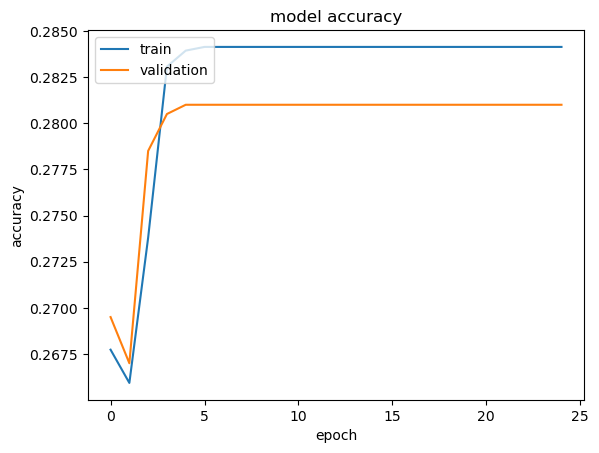

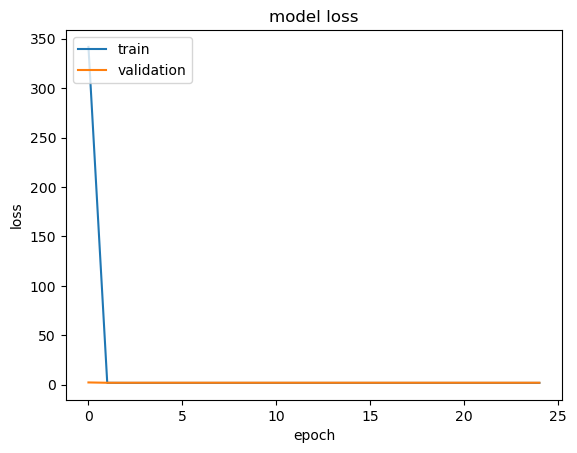

In [19]:
# callback to print learning rate at end of epoch
class LearningRateLogger(keras.callbacks.Callback):
    def __init__(self, optimizer):
        super().__init__()
        self.optimizer = optimizer

    def on_epoch_end(self, epoch, logs=None):
        lr = self.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1}: Learning rate is {lr:.6f}")
        
# Adam with exponential learning rate
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1.0,
    decay_steps=25,
    decay_rate=0.7)

optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

# Adam optimizer with exponential decay
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer = optimizer,
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Create an instance of the custom callback
lr_logger_callback = LearningRateLogger(optimizer)

history = model.fit(train_images, train_labels, epochs=25, batch_size=128, validation_data=(test_images, test_labels), callbacks=[lr_logger_callback])
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# Same model, but exponential learning rate updates once per epoch.  Starts at learning rate = 1.0

Epoch 1/25
116/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2844 - loss: 1147.6277
Epoch 1: Learning rate is 0.700000
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2836 - loss: 1127.1631 - val_accuracy: 0.2290 - val_loss: 4.4136
Epoch 2/25
110/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2570 - loss: 2.6266
Epoch 2: Learning rate is 0.490000
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2578 - loss: 2.5913 - val_accuracy: 0.2615 - val_loss: 2.7702
Epoch 3/25
109/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2898 - loss: 1.8861
Epoch 3: Learning rate is 0.343000
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2909 - loss: 1.8871 - val_accuracy: 0.3060 - val_loss: 3.0724
Epoch 4/25
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3253 - loss: 1.7942
Epoch 4: Learning rate is 0.240100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3254 - loss: 1.7939 - val_accuracy: 0.3370 - val_loss: 2.8499
Epoch 5/25
106/118 ━━━━━━━━━━━━━━━━━━━━ 0s

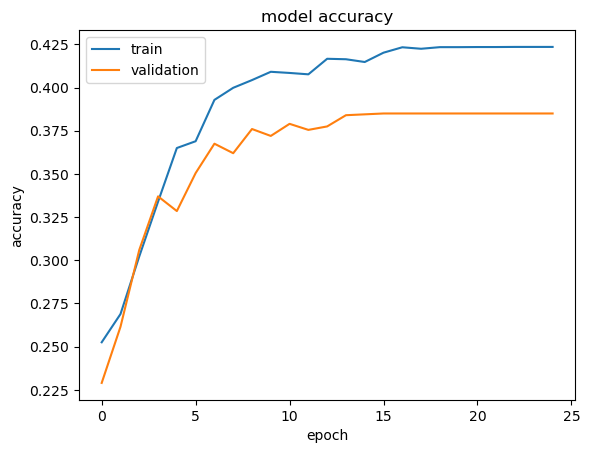

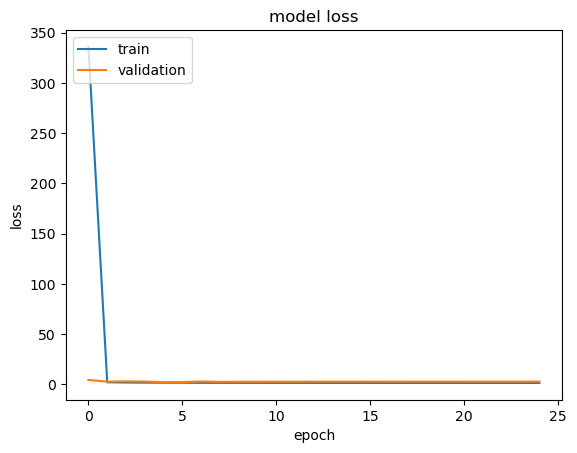

In [21]:
# callback to print learning rate at end of epoch
class LearningRateLogger(keras.callbacks.Callback):
    def __init__(self, optimizer):
        super().__init__()
        self.optimizer = optimizer

    def on_epoch_end(self, epoch, logs=None):
        lr = self.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1}: Learning rate is {lr:.6f}")
        
# Adam with exponential learning rate
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1.0,
    decay_steps=118,
    decay_rate=0.7)

optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

# Adam optimizer with exponential decay
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer = optimizer,
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Create an instance of the custom callback
lr_logger_callback = LearningRateLogger(optimizer)

history = model.fit(train_images, train_labels, epochs=25, batch_size=128, validation_data=(test_images, test_labels), callbacks=[lr_logger_callback])
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# Same model but initial learning rate 0.01 and updates every 25 batches.

Epoch 1/25
116/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7857 - loss: 0.7465
Epoch 1: Learning rate is 0.001857
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7884 - loss: 0.7371 - val_accuracy: 0.9275 - val_loss: 0.2268
Epoch 2/25
105/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9614 - loss: 0.1419
Epoch 2: Learning rate is 0.000345
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9617 - loss: 0.1402 - val_accuracy: 0.9420 - val_loss: 0.1896
Epoch 3/25
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9733 - loss: 0.1010
Epoch 3: Learning rate is 0.000064
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9732 - loss: 0.1010 - val_accuracy: 0.9405 - val_loss: 0.1882
Epoch 4/25
110/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9708 - loss: 0.1037
Epoch 4: Learning rate is 0.000012
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9710 - loss: 0.1033 - val_accuracy: 0.9415 - val_loss: 0.1874
Epoch 5/25
115/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/s

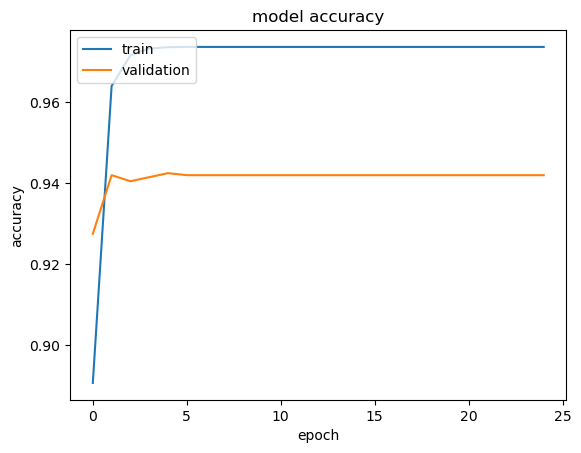

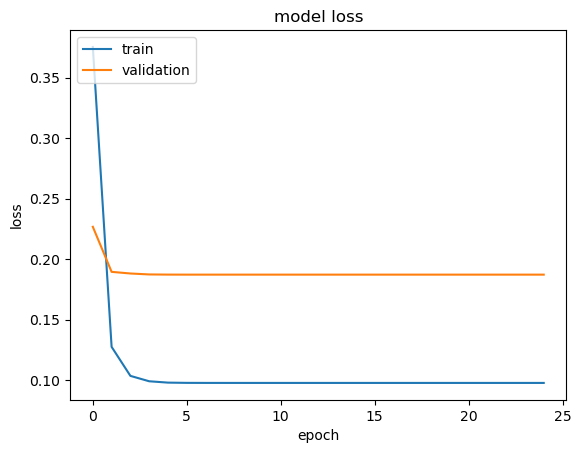

In [23]:
# callback to print learning rate at end of epoch
class LearningRateLogger(keras.callbacks.Callback):
    def __init__(self, optimizer):
        super().__init__()
        self.optimizer = optimizer

    def on_epoch_end(self, epoch, logs=None):
        lr = self.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1}: Learning rate is {lr:.6f}")
        
# Adam with exponential learning rate
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=25,
    decay_rate=0.7)

optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

# Adam optimizer with exponential decay
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer = optimizer,
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Create an instance of the custom callback
lr_logger_callback = LearningRateLogger(optimizer)

history = model.fit(train_images, train_labels, epochs=25, batch_size=128, validation_data=(test_images, test_labels), callbacks=[lr_logger_callback])
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# Same model as above but learning rate starts at 0.01 and updates once per epoch

Epoch 1/25
112/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7915 - loss: 0.6721
Epoch 1: Learning rate is 0.007000
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7974 - loss: 0.6533 - val_accuracy: 0.9290 - val_loss: 0.2235
Epoch 2/25
112/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9646 - loss: 0.1154
Epoch 2: Learning rate is 0.004900
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9648 - loss: 0.1150 - val_accuracy: 0.9475 - val_loss: 0.1825
Epoch 3/25
115/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9825 - loss: 0.0624
Epoch 3: Learning rate is 0.003430
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9825 - loss: 0.0622 - val_accuracy: 0.9550 - val_loss: 0.1457
Epoch 4/25
107/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9920 - loss: 0.0286
Epoch 4: Learning rate is 0.002401
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9921 - loss: 0.0286 - val_accuracy: 0.9655 - val_loss: 0.1343
Epoch 5/25
115/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/s

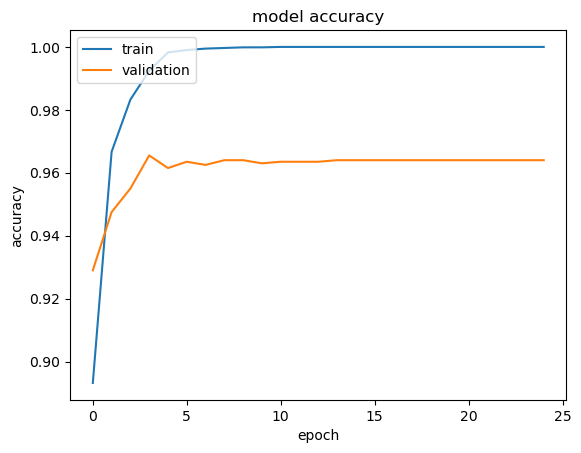

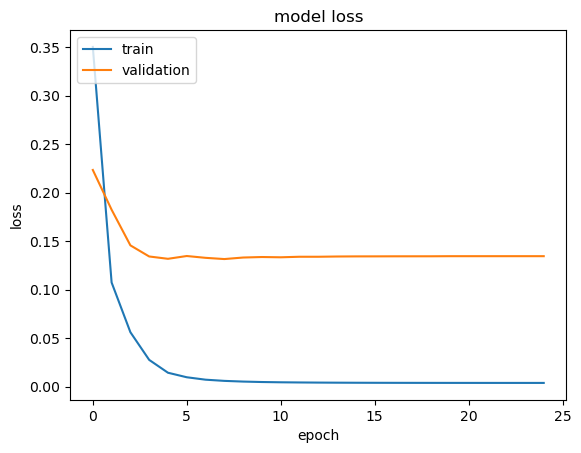

In [24]:
# callback to print learning rate at end of epoch
class LearningRateLogger(keras.callbacks.Callback):
    def __init__(self, optimizer):
        super().__init__()
        self.optimizer = optimizer

    def on_epoch_end(self, epoch, logs=None):
        lr = self.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1}: Learning rate is {lr:.6f}")
        
# Adam with exponential learning rate
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=118,
    decay_rate=0.7)

optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

# Adam optimizer with exponential decay
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer = optimizer,
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Create an instance of the custom callback
lr_logger_callback = LearningRateLogger(optimizer)

history = model.fit(train_images, train_labels, epochs=25, batch_size=128, validation_data=(test_images, test_labels), callbacks=[lr_logger_callback])
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# Batch size experiments

## 3 epochs, batch size 5.  This means 3000 forward/backward passes per epoch.
## 3000 * 3 = 9000 updates to weights

In [13]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.compile(optimizer='rmsprop',
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_images, train_labels, epochs=3, batch_size=5, validation_data=(test_images, test_labels))

Epoch 1/3
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8496 - loss: 0.4910 - val_accuracy: 0.9185 - val_loss: 0.2723
Epoch 2/3
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9546 - loss: 0.1721 - val_accuracy: 0.9395 - val_loss: 0.2544
Epoch 3/3
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9709 - loss: 0.1065 - val_accuracy: 0.9505 - val_loss: 0.2100


## 5 epochs, batch size 1024 so 15 forward/backward passes per epoch.  
## 15 * 5 = 75 updates to weights.

In [14]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.compile(optimizer='rmsprop',
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_images, train_labels, epochs=5, batch_size=1024, validation_data=(test_images, test_labels))

Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5857 - loss: 1.3555 - val_accuracy: 0.8355 - val_loss: 0.6203
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8755 - loss: 0.4771 - val_accuracy: 0.8460 - val_loss: 0.5012
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8947 - loss: 0.3796 - val_accuracy: 0.8840 - val_loss: 0.4059
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9150 - loss: 0.3100 - val_accuracy: 0.8920 - val_loss: 0.3814
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9194 - loss: 0.2831 - val_accuracy: 0.9025 - val_loss: 0.3392


## 5 epochs, batch size 5000 so 3 forward/backward passes per epoch
## 3 * 5 = 15 updates to weights

In [15]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.compile(optimizer='rmsprop',
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_images, train_labels, epochs=5, batch_size=5000, validation_data=(test_images, test_labels))

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.3428 - loss: 1.9864 - val_accuracy: 0.6740 - val_loss: 1.2998
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7244 - loss: 1.1184 - val_accuracy: 0.7225 - val_loss: 0.9804
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7933 - loss: 0.8079 - val_accuracy: 0.8145 - val_loss: 0.7734
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8510 - loss: 0.6416 - val_accuracy: 0.8070 - val_loss: 0.6962
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8440 - loss: 0.5798 - val_accuracy: 0.8120 - val_loss: 0.6523
